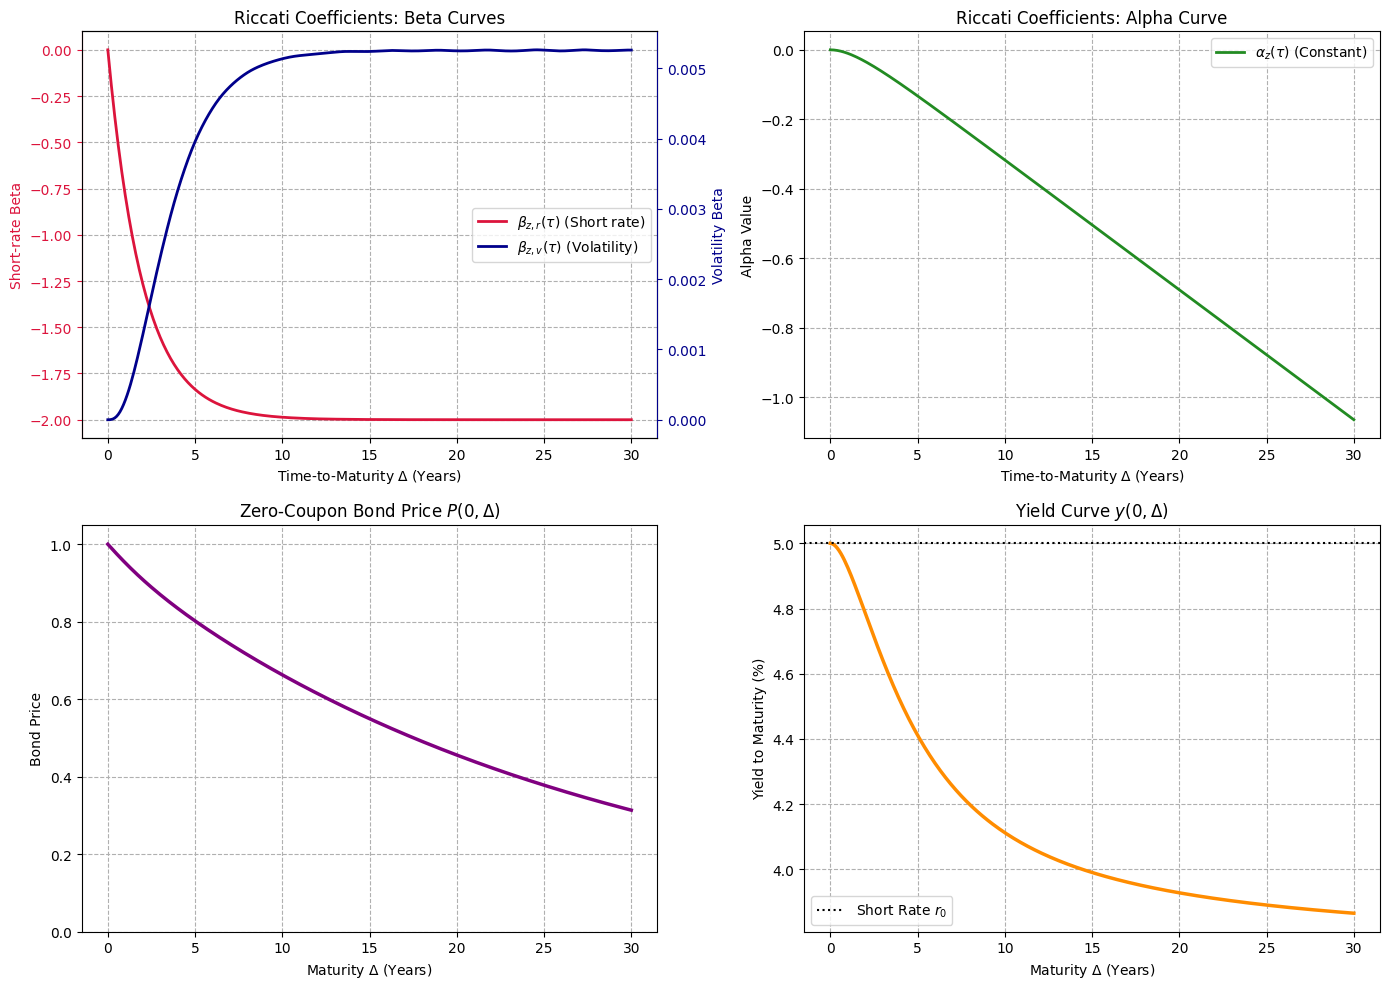

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

#Drift parameters
kappa_r, theta_r = 0.5, 0.05
kappa_v, theta_v = 1.2, 1.0

#Volatility parameters
sigma_r = 0.08
sigma_v = 1.0
rho = 0.25

#alpha-beta parameters
alpha = 0.5
beta = 0.5

#initial state values
r_0 = theta_r 
v_0 = theta_v 

#from tau = 0 to tau = 30 years
tau_max = 30.0
tau_eval = np.linspace(0, tau_max, 301)  #0.1 year steps

def riccati_system(tau, y):
    """
    y[0] = beta_r
    y[1] = beta_v
    y[2] = alpha_z
    """
    b_r, b_v, a_z = y
    
    #Common term
    vol_chunk = (sigma_r**2 * b_r**2) + (sigma_v**2 * b_v**2) + (2 * rho * sigma_r * sigma_v * b_r * b_v)
    
    #ODEs
    db_r_dtau = -kappa_r * b_r - 1.0
    db_v_dtau = -kappa_v * b_v + 0.5 * beta * vol_chunk
    da_z_dtau = kappa_r * theta_r * b_r + kappa_v * theta_v * b_v + 0.5 * alpha * vol_chunk
    
    return [db_r_dtau, db_v_dtau, da_z_dtau]

#Initial boundary conditions at tau = 0: P(T,T) = 1 => alpha=0, beta_r=0, beta_v=0
init_conditions = [0.0, 0.0, 0.0]

#Use Runge-Kutta 45
sol = solve_ivp(
    fun=riccati_system, 
    t_span=(0, tau_max), 
    y0=init_conditions, 
    t_eval=tau_eval, 
    method='RK45'
)

#Extract solutions
beta_r_curve = sol.y[0]
beta_v_curve = sol.y[1]
alpha_curve  = sol.y[2]
taus         = sol.t


#P(0, 0+tau) = exp(alpha(tau) + beta_r(tau)*r_0 + beta_v(tau)*v_0 )
discount_curve = np.exp(alpha_curve + beta_r_curve * r_0 + beta_v_curve * v_0)

#Continuously compounded yield: y(0, 0+tau) = -log(P) / tau
yield_curve = np.zeros_like(discount_curve)
yield_curve[0] = r_0    #y(0) = r_0
yield_curve[1:] = -np.log(discount_curve[1:]) / taus[1:]

#Plots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

#Plot 1: Riccati Beta Functions
ax1 = axs[0, 0]
ax2 = ax1.twinx()
p1 = ax1.plot(taus, beta_r_curve, label=r'$\beta_{z,r}(\tau)$ (Short rate)', color='crimson', lw=2)
p2 = ax2.plot(taus, beta_v_curve, label=r'$\beta_{z,v}(\tau)$ (Volatility)', color='darkblue', lw=2)
ax1.set_title("Riccati Coefficients: Beta Curves")
ax1.set_xlabel(r"Time-to-Maturity $\Delta$ (Years)")
ax1.set_ylabel("Short-rate Beta", color='crimson')
ax2.set_ylabel("Volatility Beta", color='darkblue')
ax1.grid(True, linestyle='--')
#Make y-axis ticks and spine colors match each curve
ax1.tick_params(axis='y', colors='crimson')
ax2.tick_params(axis='y', colors='darkblue')
ax1.spines['left'].set_color('crimson')
ax2.spines['right'].set_color('darkblue')
#Combine legends from both axes
lines = p1 + p2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right')

#Plot 2: Riccati Alpha Function
axs[0, 1].plot(taus, alpha_curve, label=r'$\alpha_z(\tau)$ (Constant)', color='forestgreen', lw=2)
axs[0, 1].set_title("Riccati Coefficients: Alpha Curve")
axs[0, 1].set_xlabel(r"Time-to-Maturity $\Delta$ (Years)")
axs[0, 1].set_ylabel("Alpha Value")
axs[0, 1].grid(True, linestyle='--')
axs[0, 1].legend()

#Plot 3: Discount Curve (ZCB Prices)
axs[1, 0].plot(taus, discount_curve, color='purple', lw=2.5)
axs[1, 0].set_title(r"Zero-Coupon Bond Price $P(0, \Delta)$")
axs[1, 0].set_xlabel(r"Maturity $\Delta$ (Years)")
axs[1, 0].set_ylabel("Bond Price")
axs[1, 0].set_ylim(0, 1.05)
axs[1, 0].grid(True, linestyle='--')

#Plot 4: Yield Curve
axs[1, 1].plot(taus, yield_curve * 100, color='darkorange', lw=2.5) # Convert to percentage
axs[1, 1].axhline(r_0 * 100, color='black', linestyle=':', label='Short Rate $r_0$')
axs[1, 1].set_title(r"Yield Curve $y(0, \Delta)$")
axs[1, 1].set_xlabel(r"Maturity $\Delta$ (Years)")
axs[1, 1].set_ylabel("Yield to Maturity (%)")
axs[1, 1].grid(True, linestyle='--')
axs[1, 1].legend()

plt.tight_layout()
plt.savefig("affine_diffusion_riccati_results.png")
plt.show()

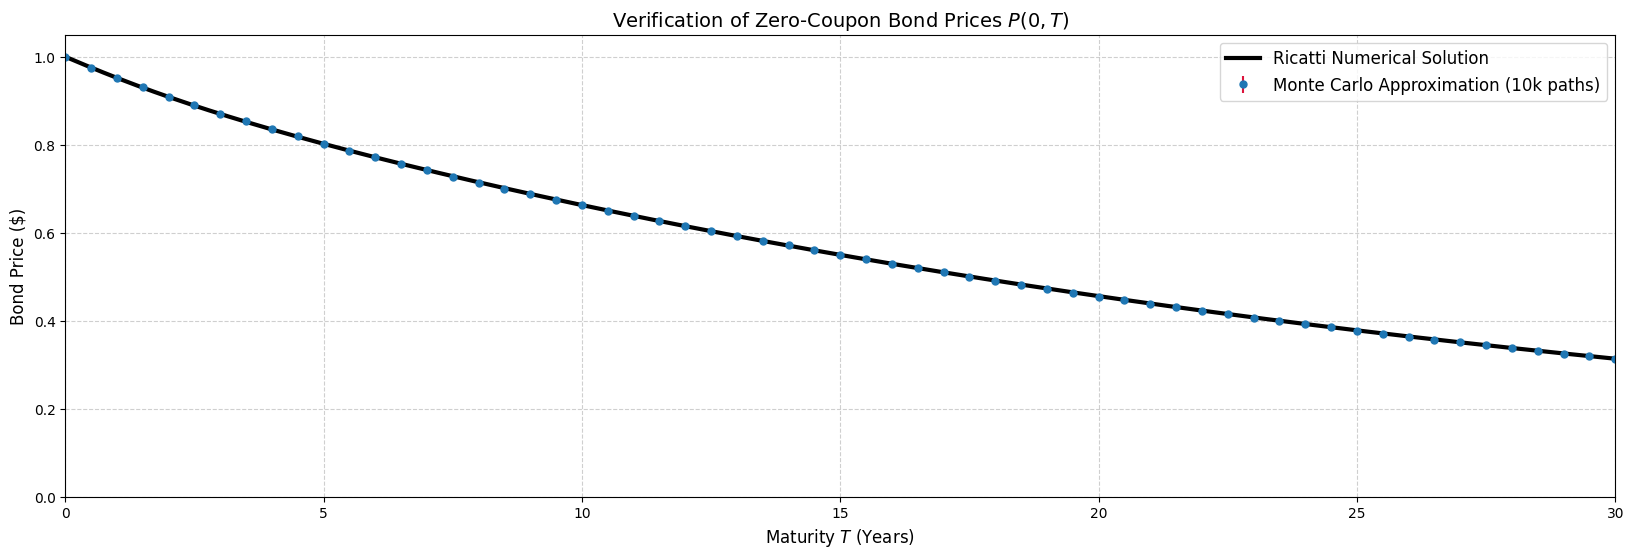

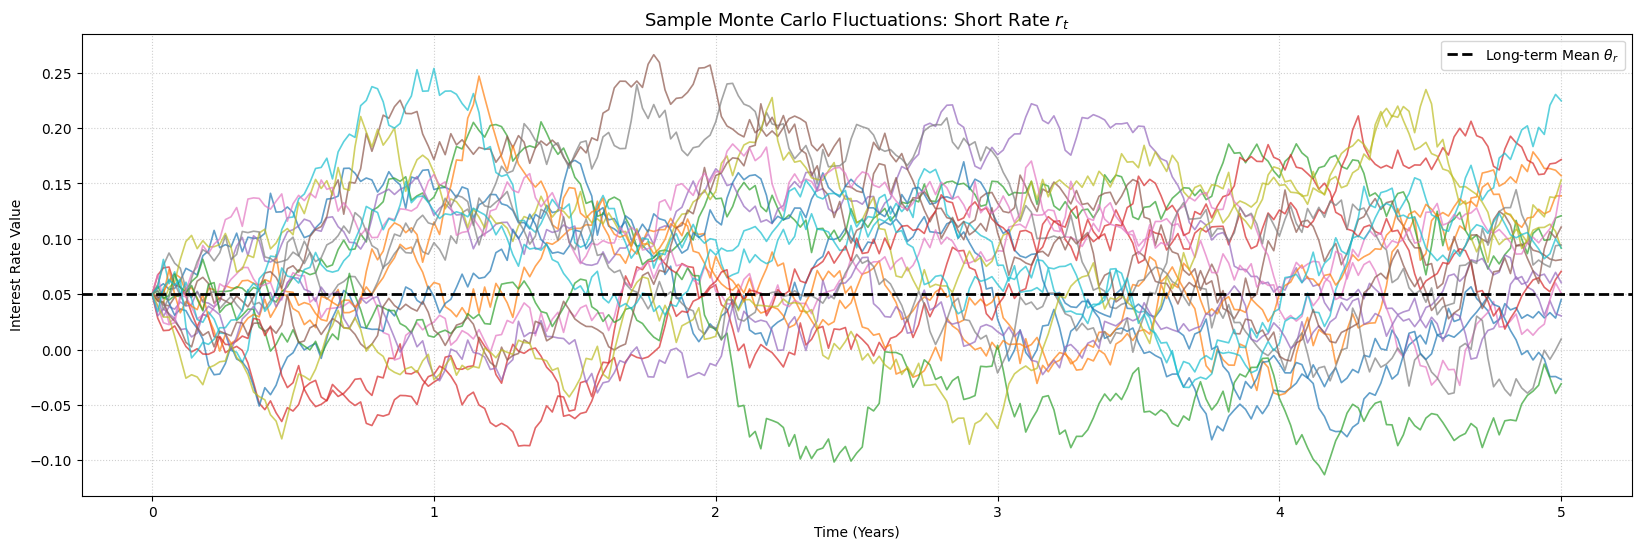

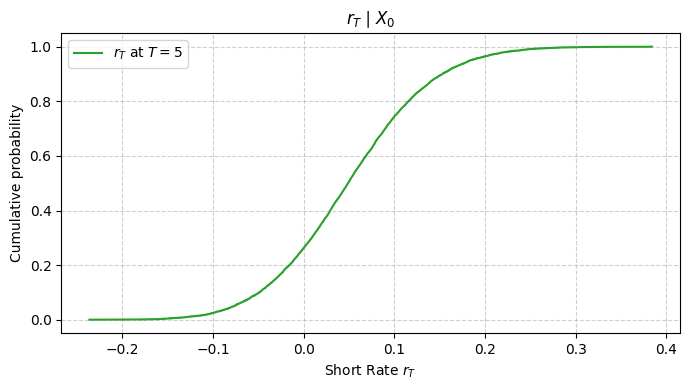

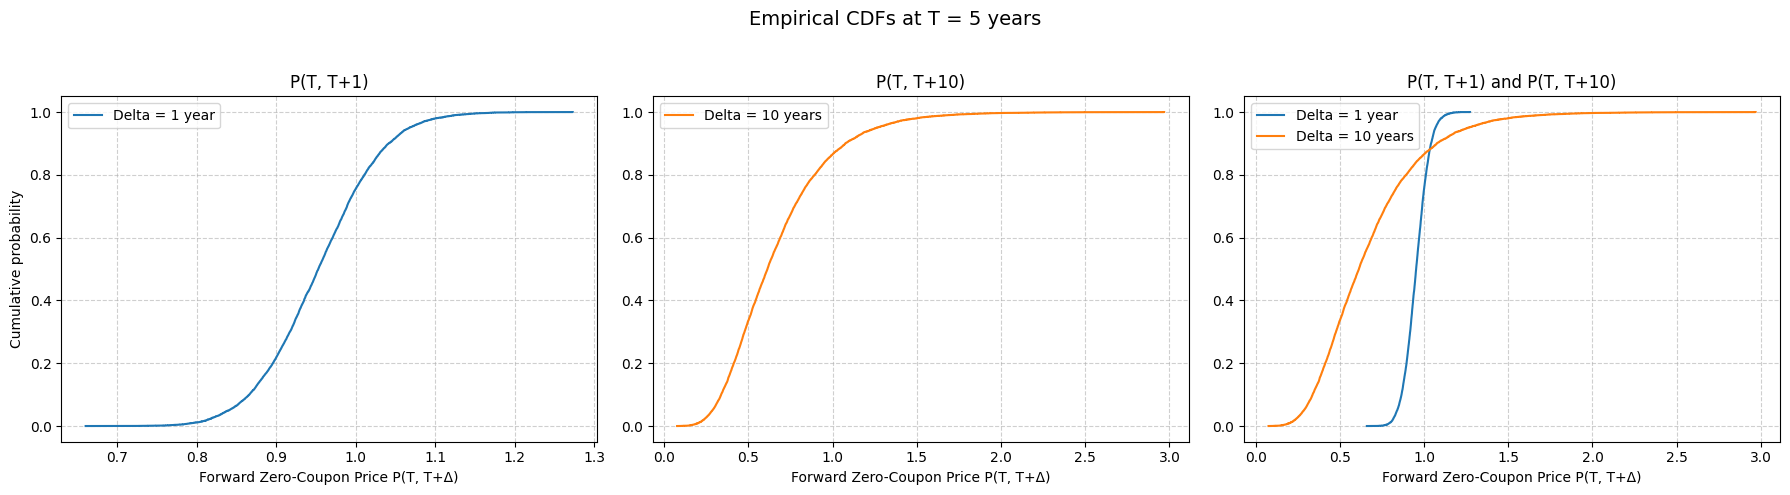

In [3]:
np.random.seed(42)

#Simulation Grid setup
T_max = 30
N_paths = 10000
N_steps = 1500
dt = T_max / N_steps
t_grid = np.linspace(0, T_max, N_steps + 1)

#Solve the ODEs on the same timeline as our simulation grid
sol = solve_ivp(riccati_system, (0, T_max), [0.0, 0.0, 0.0], t_eval=t_grid, method='RK45')
beta_r, beta_v, alpha_z = sol.y[0], sol.y[1], sol.y[2]

#Analytical prices: P(0, T)
P_analytical = np.exp(alpha_z + beta_r * r_0 + beta_v * v_0)

def MC_bond_price(T_max, N_paths, N_steps):
    r_paths = np.zeros((N_steps + 1, N_paths))
    v_paths = np.zeros((N_steps + 1, N_paths))
    log_D_paths = np.zeros((N_steps + 1, N_paths)) #Tracks the integrated running sum of -r_t * dt

    r_paths[0, :] = r_0
    v_paths[0, :] = v_0

    for i in range(N_steps):
        #Current values at step i
        r_curr = r_paths[i, :]
        v_curr = v_paths[i, :]
        
        #Generate Correlated Brownian Shocks
        Z1 = np.random.normal(0, 1, N_paths)
        Z2 = np.random.normal(0, 1, N_paths)
        W_r = Z1
        W_v = rho * Z1 + np.sqrt(1 - rho**2) * Z2
        
        #Euler-Maruyama step transitions
        r_paths[i+1, :] = r_curr + kappa_r * (theta_r - r_curr) * dt + sigma_r * np.sqrt(alpha + beta * v_curr) * np.sqrt(dt) * W_r
        v_paths[i+1, :] = v_curr + kappa_v * (theta_v - v_curr) * dt + sigma_v * np.sqrt(alpha + beta * v_curr) * np.sqrt(dt) * W_v

        #Update cumulative discount path: log(D_t) = log(D_{t-1}) - r_t * dt
        log_D_paths[i+1, :] = log_D_paths[i, :] - r_curr * dt

    #Convert log discount paths back into absolute cash discount factors
    discount_paths = np.exp(log_D_paths)

    #For every maturity step T along the grid, average the sample paths horizontally
    p_monte_carlo = np.mean(discount_paths, axis=1)
    p_monte_carlo_err = np.std(discount_paths, axis=1) / np.sqrt(N_paths)

    return p_monte_carlo, p_monte_carlo_err, r_paths, discount_paths

p_monte_carlo, p_monte_carlo_err, r_paths, discount_paths = MC_bond_price(T_max, N_paths, N_steps)

#Plots
plt.figure(figsize=(20, 6))
plt.plot(t_grid, P_analytical, label='Ricatti Numerical Solution', color='black', lw=3) #Plot analytical solution line
plt.errorbar(t_grid[::25], p_monte_carlo[::25], yerr=p_monte_carlo_err[::25], fmt='o', ecolor = 'crimson', label='Monte Carlo Approximation (10k paths)', markersize=5, alpha=1) #Plot Monte Carlo approximation markers
plt.title("Verification of Zero-Coupon Bond Prices $P(0, T)$", fontsize=14)
plt.xlabel("Maturity $T$ (Years)", fontsize=12)
plt.ylabel("Bond Price ($)", fontsize=12)
plt.xlim(0, T_max)
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.savefig("monte_carlo_verification.png", dpi=300)
plt.show()


#5-year subset for plotting a sample of short-rate paths
idx_5 = np.argmin(np.abs(t_grid - 5.0))
t_grid_5 = t_grid[:idx_5+1]
r_paths_5 = r_paths[:idx_5+1, :]

#plot only sample r paths
plt.figure(figsize=(20, 6))
N_plot_paths = 20  #Number of random paths for plotting

#r_t paths plot
for j in range(N_plot_paths):
    plt.plot(t_grid_5, r_paths_5[:, j], lw=1.2, alpha=0.7)
plt.axhline(theta_r, color='black', linestyle='--', lw=2, label=r'Long-term Mean $\theta_r$') #highlight theta_r
plt.title("Sample Monte Carlo Fluctuations: Short Rate $r_t$", fontsize=13)
plt.ylabel("Interest Rate Value")
plt.xlabel("Time (Years)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.savefig("short_rate_sample_paths.png", dpi=300)
plt.show()

#evaluate forward bond prices for Delta = 1 and Delta = 10 years by doing standard forward discounting
T_eval = 5.0

idx = np.argmin(np.abs(t_grid - T_eval))                  #Index where T = 5
idx_delta1 = np.argmin(np.abs(t_grid - (T_eval + 1)))     #Index where T = 6
idx_delta10 = np.argmin(np.abs(t_grid - (T_eval + 10)))   #index where T = 15


P_T_Tplus1 = discount_paths[idx_delta1, :] / discount_paths[idx, :]   #P(5, 6) = D(6) / D(5)
P_T_Tplus10 = discount_paths[idx_delta10, :] / discount_paths[idx, :] #P(5, 15) = D(15) / D(5)

#Short rate at T = 5 across simulated paths
r_T = r_paths[idx, :]

#Empirical CDFs
vals1 = np.sort(P_T_Tplus1)
vals10 = np.sort(P_T_Tplus10)
vals_rT = np.sort(r_T)
n = P_T_Tplus1.size
ecdf = np.arange(1, n+1) / n

#Short rate plot
plt.figure(figsize=(7, 4))
plt.step(vals_rT, ecdf, where='post', label=r'$r_T$ at $T=5$', color='tab:green')
plt.xlabel(r'Short Rate $r_T$')
plt.ylabel('Cumulative probability')
plt.title(r'$r_T \mid X_0$')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig('cdf_short_rate_T5.png')
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

#First graph: P(T, T+1)
axs[0].step(vals1, ecdf, where='post', label='Delta = 1 year', color='tab:blue')
axs[0].set_xlabel('Forward Zero-Coupon Price P(T, T+Δ)')
axs[0].set_ylabel('Cumulative probability')
axs[0].set_title('P(T, T+1)')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()

#Second graph: P(T, T+10)
axs[1].step(vals10, ecdf, where='post', label='Delta = 10 years', color='tab:orange')
axs[1].set_xlabel('Forward Zero-Coupon Price P(T, T+Δ)')
axs[1].set_title('P(T, T+10)')
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend()

#Third graph: both zero-coupon bond prices overlaid
axs[2].step(vals1, ecdf, where='post', label='Delta = 1 year', color='tab:blue')
axs[2].step(vals10, ecdf, where='post', label='Delta = 10 years', color='tab:orange')
axs[2].set_xlabel('Forward Zero-Coupon Price P(T, T+Δ)')
axs[2].set_title('P(T, T+1) and P(T, T+10)')
axs[2].grid(True, linestyle='--', alpha=0.6)
axs[2].legend()

fig.suptitle('Empirical CDFs at T = 5 years', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('cdf_forward_bond_prices_and_short_rate.png')
plt.show()

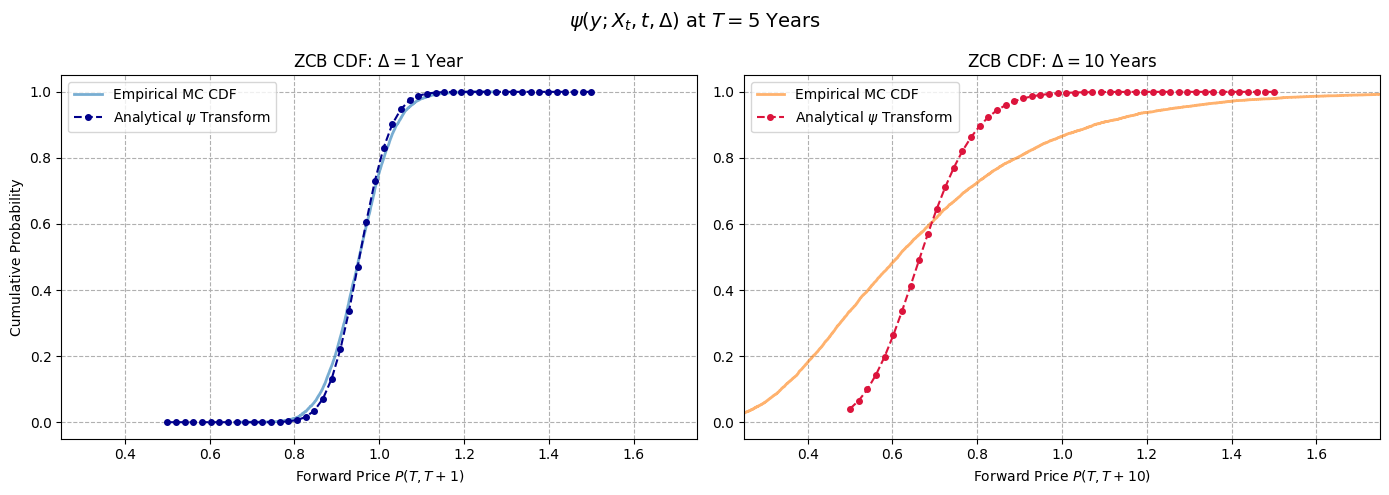

In [4]:
from scipy.integrate import quad

def chf_riccati(tau, y):
    """
    y[0] = beta_r
    y[1] = beta_v
    y[2] = alpha_z
    """
    b_r, b_v, a_z = y
    
    #Common term
    vol_chunk = (sigma_r**2 * b_r**2) + (sigma_v**2 * b_v**2) + (2 * rho * sigma_r * sigma_v * b_r * b_v)
    
    #ODEs
    db_r_dtau = -kappa_r * b_r
    db_v_dtau = -kappa_v * b_v + 0.5 * beta * vol_chunk
    da_z_dtau = kappa_r * theta_r * b_r + kappa_v * theta_v * b_v + 0.5 * alpha * vol_chunk
    
    return [db_r_dtau, db_v_dtau, da_z_dtau]

def compute_chf(k, T_eval, bz_delta):
    
    #Declare ricattii initial conditions
    initial_boundary = [1j * k * bz_delta[0], 1j * k * bz_delta[1], 0 + 0j]

    sol = solve_ivp(chf_riccati, [0, T_eval], initial_boundary, t_eval=[T_eval], method='RK45')

    Br_final, Bv_final, A_final = sol.y[:, -1]
    P_final = np.exp(A_final + Br_final * r_0 + Bv_final * v_0)

    return P_final

def compute_psi(y, az_delta, bz_delta, T_eval):
    target = np.log(y) - az_delta

    def integrand(k):
        phi = compute_chf(k, T_eval, bz_delta)
        return np.imag(phi * np.exp(-1j * k * target)) / k

    integral, _ = quad(integrand, 1e-8, np.inf, limit=400, epsabs=1e-7, epsrel=1e-7)
    return 0.5 - (1 / np.pi) * integral


#alhpa(Delta) and beta(Delta)
idx_d1 = np.argmin(np.abs(taus - 1.0)) #index where tau = 1
idx_d10 = np.argmin(np.abs(taus - 10.0)) #index where tau = 10

az_d1, bz_d1 = alpha_curve[idx_d1], np.array([beta_r_curve[idx_d1], beta_v_curve[idx_d1]])
az_d10, bz_d10 = alpha_curve[idx_d10], np.array([beta_r_curve[idx_d10], beta_v_curve[idx_d10]])

#Compute analytical cdf
y_vals = np.linspace(0.5, 1.5, 50)
psi1 = [compute_psi(y, az_d1, bz_d1, T_eval) for y in y_vals]
psi10 = [compute_psi(y, az_d10, bz_d10, T_eval) for y in y_vals]

#Plots
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

#Delta = 1
axs[0].step(vals1, ecdf, where='post', label='Empirical MC CDF', color='tab:blue', alpha=0.6, lw=2)
axs[0].plot(y_vals, psi1, 'o--', label=r'Analytical $\psi$ Transform', color='darkblue', markersize=4)
axs[0].set_title(r'ZCB CDF: $\Delta = 1$ Year')
axs[0].set_xlabel('Forward Price $P(T, T+1)$')
axs[0].set_ylabel('Cumulative Probability')
axs[0].set_xlim(0.25, 1.75)
axs[0].grid(True, linestyle='--')
axs[0].legend()

# Delta = 10
axs[1].step(vals10, ecdf, where='post', label='Empirical MC CDF', color='tab:orange', alpha=0.6, lw=2)
axs[1].plot(y_vals, psi10, 'o--', label=r'Analytical $\psi$ Transform', color='crimson', markersize=4)
axs[1].set_title(r'ZCB CDF: $\Delta = 10$ Years')
axs[1].set_xlabel('Forward Price $P(T, T+10)$')
axs[1].set_xlim(0.25, 1.75)
axs[1].grid(True, linestyle='--')
axs[1].legend()

plt.suptitle(r'$\psi(y; X_t, t, \Delta)$ at $T = 5$ Years', fontsize=14)
plt.tight_layout()
plt.savefig('analytical_vs_empirical_cdf_verification.png')
plt.show()

In [ ]:
from scipy.integrate import quad

def compute_chf2(k, T_eval):
    k = np.asarray(k, dtype=complex) #MEGET vigtigt - brugte to timer på at debugge denne ene fejl >:(
    initial_boundary = [k[0], k[1], 0]

    sol = solve_ivp(riccati_system, [0, T_eval], initial_boundary, t_eval=[T_eval], method='RK45')

    Br_final, Bv_final, A_final = sol.y[:, -1]
    P_final = np.exp(A_final + Br_final * r_0 + Bv_final * v_0)

    return P_final


def compute_G1(x, az_delta, bz_delta, T_eval):
    target = np.log(x) - az_delta
    
    def integrand(v):
        k = 1j * v * bz_delta
        phi = compute_chf2(k, T_eval)
        return np.imag(phi * np.exp(-1j * v * target)) / v

    integral, _ = quad(integrand, 1e-2, np.inf, limit=400)
    G1 = 0.5 *  compute_chf2(np.array([0, 0]), T_eval)  - (1 / np.pi) * integral

    return G1


def compute_G2(x, az_delta, bz_delta, T_eval):
    target = np.log(x) - az_delta
    
    def integrand(v):
        k = 1j * v * bz_delta +  bz_delta
        phi = compute_chf2(k, T_eval)
        return np.imag(phi * np.exp(-1j * v * target)) / v

    integral, _ = quad(integrand, 1e-2, np.inf, limit=400)
    G2 = np.exp(az_delta) * (0.5 * compute_chf2(bz_delta + 0j, T_eval) - (1 / np.pi) * integral)

    return G2


T_eval = 5

G1_d1_empirical = []
G2_d1_empirical = []
G1_d10_empirical = []
G2_d10_empirical = []

idx_t5 = np.argmin(np.abs(t_grid - 5)) #index where T = 5
idx_t6 = np.argmin(np.abs(t_grid - 6)) #index where T = 6
idx_t15 = np.argmin(np.abs(t_grid - 15)) #Index where T = 15

idx_tau1 = np.argmin(np.abs(taus - 1)) #index where tau = 1
idx_tau10 = np.argmin(np.abs(taus - 10)) #index where tau = 10

#Determine empirical ZCP prices for each path by forward discounting from T to T+Delta
D_T = discount_paths[idx_t5, :]
P_T_Tplus1 = discount_paths[idx_t6, :] / discount_paths[idx_t5, :]
P_T_Tplus10 = discount_paths[idx_t15, :] / discount_paths[idx_t5, :]

for x in y_vals:
    indicator1 = (P_T_Tplus1 <= x)
    G1_d1_empirical.append(np.mean(D_T * indicator1))                   #E[D_T * 1{P(T, T+1) <= x}]
    G2_d1_empirical.append(np.mean(D_T * P_T_Tplus1 * indicator1))      #E[D_T * P(T, T+1) * 1{P(T, T+1) <= x}]
    indicator10 = (P_T_Tplus10 <= x)
    G1_d10_empirical.append(np.mean(D_T * indicator10))                 #E[D_T * 1{P(T, T+10) <= x}]
    G2_d10_empirical.append(np.mean(D_T * P_T_Tplus10 * indicator10))   #E[D_T * P(T, T+10) * 1{P(T, T+10) <= x}]


#Note that P(t, T + Delta)/P(t, T) = P(T, T + Delta) is the forward price at time t for delivery at T.

#alhpa(Delta) and beta(Delta)
az_d1, bz_d1 = alpha_curve[idx_tau1], np.array([beta_r_curve[idx_tau1], beta_v_curve[idx_tau1]])
az_d10, bz_d10 = alpha_curve[idx_tau10], np.array([beta_r_curve[idx_tau10], beta_v_curve[idx_tau10]])

#Analytical computations
G1_d1_analytical = [compute_G1(x, az_d1, bz_d1, T_eval) for x in y_vals]
G2_d1_analytical = [compute_G2(x, az_d1, bz_d1, T_eval) for x in y_vals]
G1_d10_analytical = [compute_G1(x, az_d10, bz_d10, T_eval) for x in y_vals]
G2_d10_analytical = [compute_G2(x, az_d10, bz_d10, T_eval) for x in y_vals]

#plot delta 1
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].plot(y_vals, G1_d1_empirical, '-', label='Empirical Monte Carlo', color='tab:blue', lw=2.5)
axs[0].plot(y_vals, G1_d1_analytical, 'o--', label='Analytical $G_1(x)$ Transform', color='darkblue', markersize=5)
axs[0].set_title(r'$G_1(x)$')
axs[0].set_xlabel('$x$')
axs[0].set_ylabel('Discounted Value')
axs[0].grid(True, linestyle='--')
axs[0].legend()

axs[1].plot(y_vals, G2_d1_empirical, '-', label='Empirical Monte Carlo', color='tab:orange', lw=2.5)
axs[1].plot(y_vals, G2_d1_analytical, 'o--', label='Analytical $G_2(x)$ Transform', color='crimson', markersize=5)
axs[1].set_title(r'$G_2(x)$')
axs[1].set_xlabel('$x$')
axs[1].grid(True, linestyle='--')
axs[1].legend()

plt.suptitle(r'Verification of $G$-Transforms at $T = 5, \Delta = 1$', fontsize=14)
plt.tight_layout()
plt.savefig('discounted_g_transform_verification_delta1.png')
plt.show()

#plot delta 10
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].plot(y_vals, G1_d10_empirical, '-', label='Empirical Monte Carlo', color='tab:blue', lw=2.5)
axs[0].plot(y_vals, G1_d10_analytical, 'o--', label='Analytical $G_1(x)$ Transform', color='darkblue', markersize=5)
axs[0].set_title(r'$G_1(x)$')
axs[0].set_xlabel('$x$')
axs[0].set_ylabel('Discounted Value')
axs[0].grid(True, linestyle='--')
axs[0].legend()

axs[1].plot(y_vals, G2_d10_empirical, '-', label='Empirical Monte Carlo', color='tab:orange', lw=2.5)
axs[1].plot(y_vals, G2_d10_analytical, 'o--', label='Analytical $G_2(x)$ Transform', color='crimson', markersize=5)
axs[1].set_title(r'$G_2(x)$')
axs[1].set_xlabel('$x$')
axs[1].grid(True, linestyle='--')
axs[1].legend()

plt.suptitle(r'Verification of $G$-Transforms at $T = 5, \Delta = 10$', fontsize=14)
plt.tight_layout()
plt.savefig('discounted_g_transform_verification_delta10.png') 
plt.show()


C:\Users\Ben12\AppData\Local\Temp\ipykernel_9272\3331010184.py:23: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral, _ = quad(integrand, 1e-2, np.inf, limit=400)
C:\Users\Ben12\AppData\Local\Temp\ipykernel_9272\3331010184.py:37: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral, _ = quad(integrand, 1e-2, np.inf, limit=400)


In [ ]:
K = 0.97
T_eval = 5

#since discount_curve is built up directly from the ricatti solutions, we should index over the tau grid
idx_tau5 = np.argmin(np.abs(taus - 5)) #index where tau = 5
idx_tau6 = np.argmin(np.abs(taus - 6)) #index where tau = 6

P_0_5 = discount_curve[idx_tau5]  #P(0, 5)
P_0_6 = discount_curve[idx_tau6]  #P(0, 6)

g1_K = compute_G1(K, az_d1, bz_d1, T_eval)
g2_K = compute_G2(K, az_d1, bz_d1, T_eval)

ZCC_analytical = P_0_6 - g2_K - K * P_0_5 + K * g1_K
ZCP_analytical = K * g1_K - g2_K

call_payoffs = np.maximum(P_T_Tplus1 - K, 0)
put_payoffs  = np.maximum(K - P_T_Tplus1, 0)

ZCC_empirical = np.mean(D_T * call_payoffs)
ZCP_empirical = np.mean(D_T * put_payoffs)

parity_lhs = ZCC_analytical - ZCP_analytical
parity_rhs = P_0_6 - P_0_5 * K

print(f"Analytical ZCC Price: {np.real(ZCC_analytical):.6f}")
print(f"Analytical ZCP Price: {np.real(ZCP_analytical):.6f}")
print(f"Empirical ZCC Price: {np.real(ZCC_empirical):.6f}")
print(f"Empirical ZCP Price: {np.real(ZCP_empirical):.6f}")
print(f"Put-Call Parity Check: LHS (analytical) = {np.real(parity_lhs):.6f}, RHS (empirical) = {np.real(parity_rhs):.6f}")

NameError: name 'np' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

K_star = P_0_6 / P_0_5
T = 5
d = 0.2
n = 10

# 1. Define Strike Arrays
i_grid = np.arange(0, n + 1)
kp_strikes = K_star - d * (1.0 - i_grid / n)
kc_strikes = K_star + d * (i_grid / n)


def black_scholes_price(F, K, T, sigma, option_type='call'):
    d1 = (np.log(F / K) + 0.5 * (sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        return P_0_5 * (F * norm.cdf(d1) - K * norm.cdf(d2))
    else:
        return P_0_5 * (K * norm.cdf(-d2) - F * norm.cdf(-d1))

def find_implied_vol(market_price, F, K, T, option_type='call'):
    def obj_func(sigma):
        return black_scholes_price(F, K, T, sigma, option_type) - market_price

    #volatility between 10^-4 and 4
    return brentq(obj_func, 1e-4, 4.0)



<>:96: SyntaxWarning: invalid escape sequence '\s'
<>:97: SyntaxWarning: invalid escape sequence '\s'
<>:96: SyntaxWarning: invalid escape sequence '\s'
<>:97: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Ben12\AppData\Local\Temp\ipykernel_26420\290151131.py:96: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(kp_strikes, put_vols_m1, 'ro-', label='Model 1 ($\sigma_v=2$) Puts')
C:\Users\Ben12\AppData\Local\Temp\ipykernel_26420\290151131.py:97: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(kc_strikes, call_vols_m1, 'r*--', label='Model 1 ($\sigma_v=2$) Calls')


ValueError: f(a) and f(b) must have different signs